%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import pickle
import dill
import numpy as np
import scipy as sp
import pandas as pd
import warnings
from tqdm import tqdm
import astropy
from astropy import stats

from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns
sns.set_style("white")

from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
from reward_relative import regression
    

save_figures = False

In [ ]:
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
import pickle
import dill

In [3]:
path_dict

{'preprocessed_root': '/data/2p_data',
 'sbx_root': '/media/sosalab/T7/2p_raw_data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2p_data/VR_Data',
 'git_repo_root': '/home/sosalab/local_repos',
 'TwoPUtils': '/home/sosalab/local_repos/TwoPUtils',
 'home': '/home/sosalab',
 'fig_dir': '/data/2p_data/fig_scratch'}

In [4]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2p_data/fig_scratch/Apr2026


## Load pre-saved multiDayData

To make multiDayData, run `make_multiDayData_class.ipynb`

In [5]:
experiment = 'MetaLearn'
year = 'combined'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment, exp_days, year=year)

## These parameters were used for computing the saved multiDayData
# bin_size = 10  # for quantifying distribution of place field peak locations
# sigma = 1  # for smoothing
# smooth = False  # whether to smooth for finding place cell peaks
# exclude_int = True  # exclude putative interneurons
# int_thresh = 0.5

## Place cell logical definitions:
## 'and' = must have significant spatial information
## in trial set 0 AND trial set 1 (i.e. before and after the reward switch)
## 'or' = must have signitive spatial information in trial set 0 OR trial set 1

# place_cell_logical = 'or'
ts_key = 'dff'  # which timeseries to use for finding peaks
# use_speed_thr = True  # use a speed threshold to calculate new trial matrices
# # speed threshold in cm/s (excludes data at speed less than this)
# speed_thr = 2

reward_dist_inclusive = 50  # in cm

# datetime of saved file
dt = "202504"

pkl_name = "%s_expdays%s_multiDayData_%s_%s.pickle" % (
    # ut.make_anim_tag(max_anim_list),
    f'm{ut.get_mouse_number(max_anim_list[0])}-{ut.get_mouse_number(max_anim_list[-1])}',
    ut.make_day_tag(
        exp_days),
    ts_key,
    dt)
pkl_path = os.path.join(
    path_dict['preprocessed_root'], 'multi_anim_sess', pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path, "rb"), ignore=True)

include_ans = multiDayData[exp_days[-1]
                           ].circ_rel_stats_across_an['include_ans']
max_anim_list = sorted(np.unique(np.concatenate([multiDayData[day].anim_list
                                                 for day in exp_days])),
                       key=len)
include_ans

/data/2p_data/multi_anim_sess/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


array(['GCAMP3', 'GCAMP4', 'GCAMP7', 'GCAMP11', 'GCAMP12', 'GCAMP13',
       'GCAMP14', 'GCAMP15', 'GCAMP17', 'GCAMP18', 'GCAMP19'], dtype='<U7')

## Inspect cells by remapping type

PLEASE READ A NOTE ABOUT CELL CLASSIFICATION:

Note that the order of operations in the study was to characterize remapping  \
agnostic of whether cells were "reward-relative", and then investigate the  \
"reward-relative" hypothesis.

Once we start considering reward-relative cells, there can technically be  \
some overlap with the other categories, so we exclude the reward-relative  \
cells from those categories from further analysis. This is because reward-  \
relative (RR) cells are not required to have "significant" spatial information (SI)  \
both before and after the reward switch, as we found that was unneccesarily  \
restrictive (but note, requiring sig. SI before and after did not qualitatively  \
change the main results, just reduced the number of cells considered). In addition,  \
"appearing" and "disappearing" are defined by thresholds of activity change, such that  \
if a cell shows drastic rate-remapping but the location of the activity before and after  \
is reliably reward-relative, the cell could be counted as reward-relative as well as \
originally being counted as "appearing", for instance. So, in sum, RR cells \
can occasionally fall into the original "appearing", "disappearing", and of course  \
"reward" and "nonreward_remap" (called "remap far from reward" in the paper) categories,  \
though almost never into the "track-relative" group. 

Once the 2 criteria for identifying reward-relative cells are applied (see Methods of the paper; \
[1] firing peaks must be ≤0.698 radians from each other in reward-relative coordinates, \
[2] peak of the cross-correlation between pre- and post-switch firing patterns must exceed a shuffle) \
"reward-relative" cells are excluded from all other categories for quantification purposes.

Once "reward-relative" are excluded from nonreward_remap, the remaining nonreward_remap cells \
are the "non-reward-relative remapping cells" described in the paper. 

Note: there can also be "reward" cells that are not also "reward-relative" if their  \
peak firing is within 50 cm of both reward locations (within a 100 cm span on either side  \
the reward zone start) but not within 50 cm of _each other_ relative to reward (50 cm span). 

These cell categories are meant to be a descriptive way to capture the heterogeneity  \
of remapping patterns. They are not meant to assign biologically meaningful "cell types",  \
even though I use `cell_class` as a shorthand in the code.

A lot of time was spent exploring the various thresholds involved here, and we  \
did not find that changing any of them changed the conclusion, which is that reward-relative  \
coding exists at the population level. 


#### Relationship of keys used here to remapping categories in the paper:

'track' = track-relative  \
'disappear' = disappearing  \
'appear' = appearing  \
'reward' = remap near reward (≤50 cm from both reward zone starts)  \
'rr' = reward-relative  \
'reward_inc_rr' = remap near reward, including reward-relative  \
'nonreward_remap_inc_rr' = remap far from reward (>50 cm from reward zone start), including reward-relative  \
'nonreward_remap' = non-reward-relative (non-RR) remapping  \
'unclassified' = cells that did not fall into any of the above groups  \

In [6]:
## Get cell indices by remapping type
example_day = 14
example_an = 'GCAMP4' # corresponds to mouse "m14"
## to exclude RR cells from other categories, set 'exclude_rr_from_others' to True
_, cell_inds = dd.get_cell_class_n(multiDayData, example_day, example_an, exclude_rr_from_others=True, verbose=True)


excluding 0 from 189 track
excluding 10 from 82 disappear
excluding 4 from 58 appear
excluding 24 from 31 reward
excluding 15 from 85 nonreward_remap


In [7]:
cell_inds.keys()

dict_keys(['rr', 'track', 'disappear', 'appear', 'reward_inc_rr', 'reward', 'nonreward_remap_inc_rr', 'nonreward_remap', 'unclassified'])

In [8]:
# load multi_anim_sess that has the spatial activity to plot
multi_anim_sess = dd.load_multi_anim_sess(path_dict, example_day, multiDayData[example_day].anim_list,
                                          subdirs = ['multi_anim_sess'])

### Plot example place cells by remapping type

/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/IPython/core/events.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/sosalab/miniconda3/envs/dope2p2025_tests/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


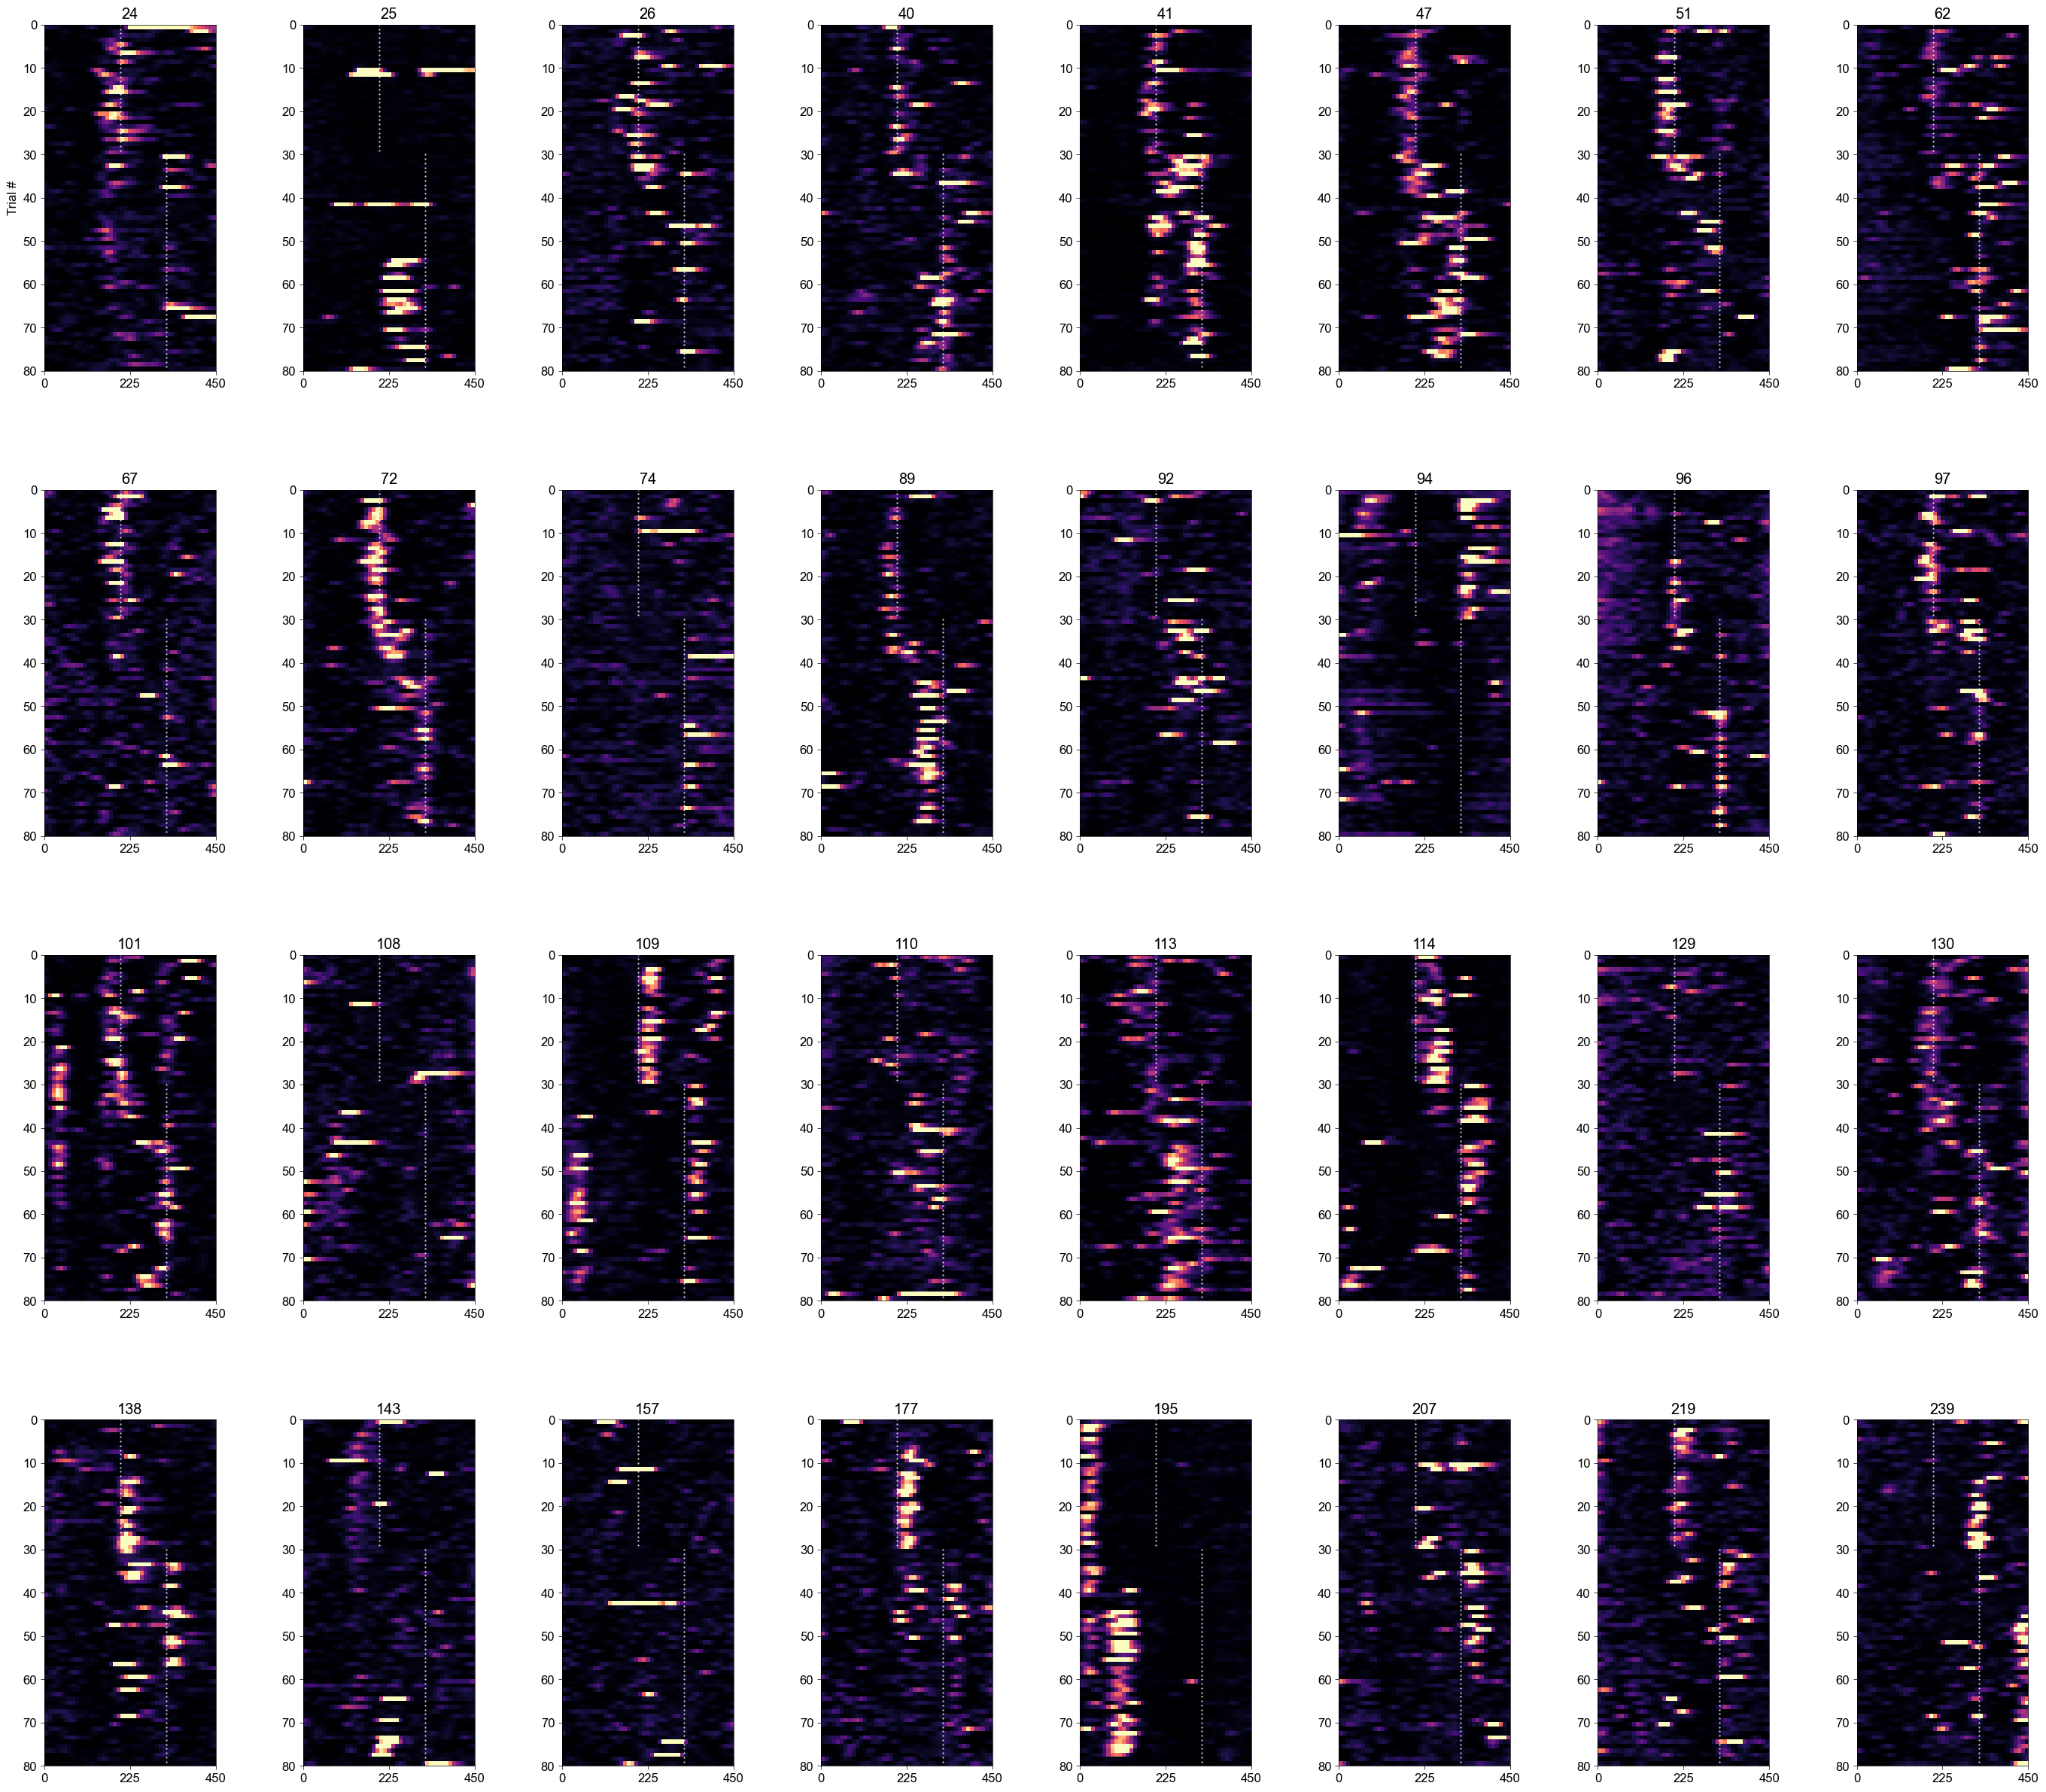

In [9]:
## Plot trials x spatial bins activity matrix for each cell
## White lines are beginnings of reward zones

category_to_plot = 'rr'

fig = placeCellPlot.plot_all_single_cells(multi_anim_sess[example_an]['sess'],
                                          cell_inds[category_to_plot],
                                          ts_key='events',
                                          normalization_method='mean', # options: 'mean', 'max', 'zscore'
                                          max_cells=32,
                                          plot_reward_zone=True,
                                          sigma=1, # Gaussian smoothing, sd in bins
                                          use_speed_thr=True,
                                          circ_shift=False, # set True to circularly align reward zones
                                          )

In [ ]:
# 239 looks like it tiles off the edge
#114 looks like a relatively simple example of rr

In [16]:
sess = multi_anim_sess[example_an]['sess']
cell = sess.trial_matrices['events'][0][:,:,239]

In [ ]:
sess.timeseries['events']

(1066, 51520)

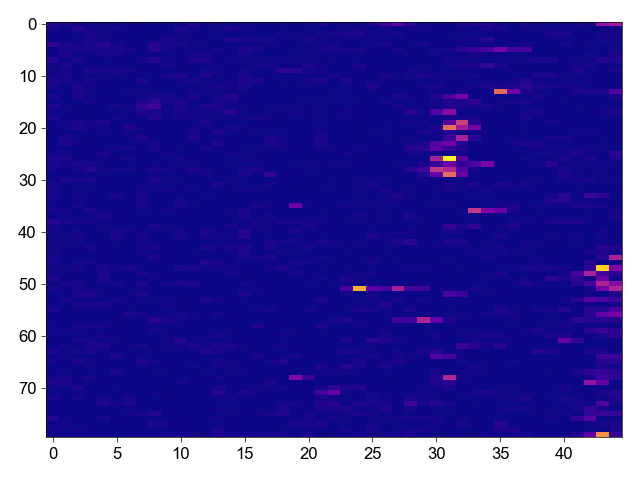

In [21]:
%matplotlib widget
fig, ax = plt.subplots()
# tm = np.copy(sess.trial_matrices['events'])
ax.imshow(cell, cmap='plasma', #extent=(tm[-2][0], tm[-2][-1], 80, 0),
                    aspect='auto',
                    )

In [26]:
cell_idx = 114
cell = sess.trial_matrices['events'][0][:,:,cell_idx]
np.save(f'/home/sosalab/local_repos/Sosa_et_al_2024/notebooks/protter_tmp_files/cell_gcamp4_d14_{cell_idx}.npy', cell)

In [27]:
cell_idx = 239
cell = sess.trial_matrices['events'][0][:,:,cell_idx]
np.save(f'/home/sosalab/local_repos/Sosa_et_al_2024/notebooks/protter_tmp_files/cell_gcamp4_d14_{cell_idx}.npy', cell)

In [62]:
import TwoPUtils
# Get the trial-by-trial activity, at speeds > speed_thr
tm = TwoPUtils.spatial_analyses.trial_matrix(sess.timeseries['events'].T,
                                                sess.vr_data['pos']._values,
                                                sess.trial_start_inds,
                                                sess.teleport_inds,
                                                bin_size=1,
                                                min_pos=0,
                                                max_pos=450,
                                                speed_thr=2,
                                                speed=sess.vr_data['speed']._values,
                                                impute_nans = True
                                                )

/home/sosalab/local_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


In [57]:
tm_df = TwoPUtils.spatial_analyses.trial_matrix(sess.timeseries['dff'].T,
                                                sess.vr_data['pos']._values,
                                                sess.trial_start_inds,
                                                sess.teleport_inds,
                                                bin_size=1,
                                                min_pos=0,
                                                max_pos=450,
                                                speed_thr=2,
                                                speed=sess.vr_data['speed']._values
                                                )

/home/sosalab/local_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


In [63]:
rep_na = np.nan_to_num(tm[0][:,:,239])


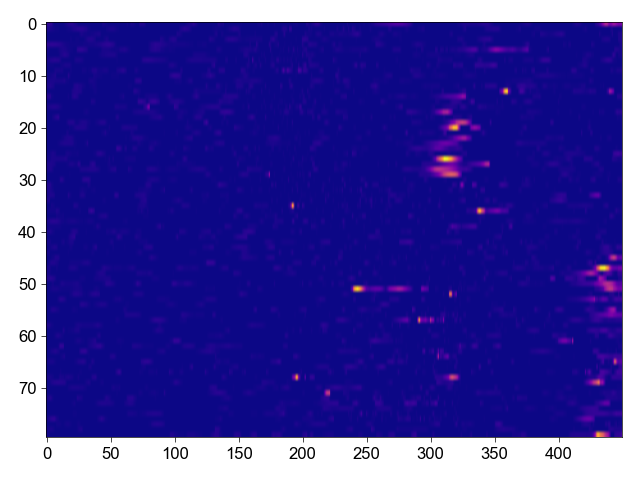

In [64]:
fig, ax = plt.subplots()
# tm = np.copy(sess.trial_matrices['events'])
ax.imshow(rep_na, cmap='plasma', #extent=(tm[-2][0], tm[-2][-1], 80, 0),
                    aspect='auto',
                    )

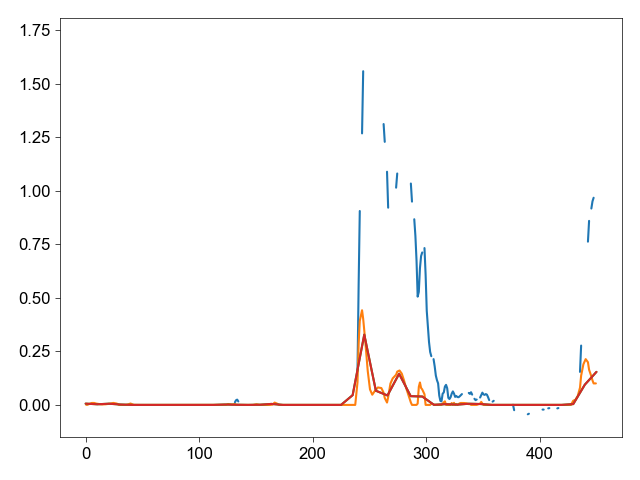

In [65]:
fig, ax = plt.subplots()
trial = 51
ax.plot(tm_df[3], tm_df[0][trial,:,239])
ax.plot(tm[3], rep_na[trial])

track = np.linspace(0, 450, 45)
ax.plot(track, sess.trial_matrices['events'][0][trial,:,239])
ax.plot(track, sess.trial_matrices['events'][0][trial,:,239])

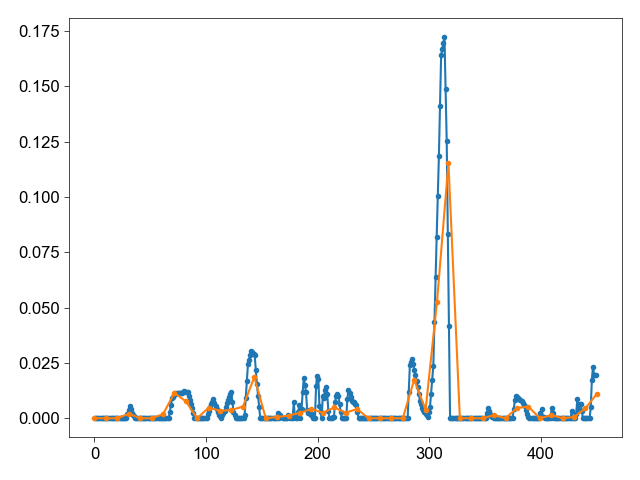

In [69]:
fig, ax = plt.subplots()
trial = 17
ax.plot(tm[3], rep_na[trial], '.-')

track = np.linspace(0, 450, 45)
ax.plot(track, sess.trial_matrices['events'][0][trial,:,239], '.-')